## Лабораторная работа №6
**Выполнил:** Хрипков Тимофей, группа ИУ5-65Б

### Цель работы
1. Исследование необходимых и достаточных условий существования экстремума функции с учётом ограничений (условный экстремум).
2. Вычисление экстремумов функции.

### Цель работы
1. Исследование необходимых и достаточных условий существования экстремума функции с учётом ограничений (условный экстремум).
2. Вычисление экстремумов функции.

### Задание (вариант 5)

$$f(x) = 4x_1^2 + 4x_1 + x_2^2 - 8x_2 + 5 \to \text{extr}$$

$$\begin{cases}
g_1(x) = 2x_1 + x_2 - 6 \leq 0, \\
g_2(x) = -x_1 \leq 0, \\
g_3(x) = -x_2 \leq 0.
\end{cases}$$


Множество допустимых решений $X \subseteq \mathbb{R}^2$: найти все точки условных локальных минимумов и максимумов.


In [ ]:
# %%
# Установка необходимых библиотек (если не установлены)
import importlib, subprocess, sys
if importlib.util.find_spec('sympy') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'sympy', '-q'], check=True)
if importlib.util.find_spec('matplotlib') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib', '-q'], check=True)
if importlib.util.find_spec('numpy') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'numpy', '-q'], check=True)

In [ ]:
# %%
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from itertools import product as iproduct


### Постановка задачи в символьном виде


In [ ]:
# %%
x1, x2 = sp.symbols('x1 x2', real=True)
l1, l2, l3 = sp.symbols('lambda1 lambda2 lambda3', real=True)

# Целевая функция
f = 4*x1**2 + 4*x1 + x2**2 - 8*x2 + 5

# Ограничения g_j(x) <= 0
g1 = 2*x1 + x2 - 6
g2 = -x1
g3 = -x2

print("f(x) =", f)
print("g1(x) =", g1, "<= 0")
print("g2(x) =", g2, "<= 0")
print("g3(x) =", g3, "<= 0")

f(x) = 4*x1**2 + 4*x1 + x2**2 - 8*x2 + 5
g1(x) = 2*x1 + x2 - 6 <= 0
g2(x) = -x1 <= 0
g3(x) = -x2 <= 0


### Преобразование целевой функции (выделение полных квадратов)

$$f(x) = 4x_1^2 + 4x_1 + x_2^2 - 8x_2 + 5 = 4\left(x_1 + \frac{1}{2}\right)^2 + (x_2 - 4)^2 - 12$$


In [ ]:
f_completed = 4*(x1 + sp.Rational(1,2))**2 + (x2 - 4)**2 - 12
print("f(x) в виде полных квадратов:", f_completed)
print("Безусловный минимум: точка (-0.5, 4), f = -12")
print("Эта точка НЕ принадлежит допустимой области (x1 < 0)")


f(x) в виде полных квадратов: 4*(x1 + 1/2)**2 + (x2 - 4)**2 - 12
Безусловный минимум: точка (-0.5, 4), f = -12
Эта точка НЕ принадлежит допустимой области (x1 < 0)


### Классическая функция Лагранжа и условия стационарности

Функция Лагранжа:
$$L(x, \lambda) = f(x) + \lambda_1 g_1(x) + \lambda_2 g_2(x) + \lambda_3 g_3(x)$$

Необходимые условия (условия ККТ):
- Стационарность: $\nabla_x L = 0$
- Допустимость: $g_j(x) \leq 0$
- Неотрицательность: $\lambda_j \geq 0$ (для min)
- Дополняющая нежёсткость: $\lambda_j \cdot g_j(x) = 0$


In [ ]:
# %%
L = f + l1*g1 + l2*g2 + l3*g3

dL_x1 = sp.diff(L, x1)
dL_x2 = sp.diff(L, x2)

print("dL/dx1 =", sp.simplify(dL_x1))
print("dL/dx2 =", sp.simplify(dL_x2))

dL/dx1 = 2*lambda1 - lambda2 + 8*x1 + 4
dL/dx2 = lambda1 - lambda3 + 2*x2 - 8


### Поиск стационарных точек: перебор случаев активности ограничений


In [ ]:
# %%
g_list = [g1, g2, g3]
l_list = [l1, l2, l3]
all_vars = [x1, x2, l1, l2, l3]
stationarity = [dL_x1, dL_x2]

kkt_candidates = []

for mask in iproduct([0, 1], repeat=3):
    eqs = list(stationarity)
    for j, (g, lam, active) in enumerate(zip(g_list, l_list, mask)):
        if active:
            eqs.append(g)
        else:
            eqs.append(lam)

    try:
        sols = sp.solve(eqs, all_vars, dict=True)
    except Exception:
        sols = []

    for sol in sols:
        try:
            x1v = complex(sp.N(sol.get(x1, 0))).real
            x2v = complex(sp.N(sol.get(x2, 0))).real
            l1v = complex(sp.N(sol.get(l1, 0))).real
            l2v = complex(sp.N(sol.get(l2, 0))).real
            l3v = complex(sp.N(sol.get(l3, 0))).real
        except Exception:
            continue

        if not all(np.isfinite(v) for v in [x1v, x2v, l1v, l2v, l3v]):
            continue

        if x1v < -1e-6 or x2v < -1e-6:
            continue
        g1v = 2*x1v + x2v - 6
        if g1v > 1e-6:
            continue

        fv = 4*x1v**2 + 4*x1v + x2v**2 - 8*x2v + 5
        lambdas = [l1v, l2v, l3v]

        kkt_candidates.append({
            'x1': round(x1v, 6), 'x2': round(x2v, 6),
            'f': round(fv, 6),
            'l1': round(l1v, 6), 'l2': round(l2v, 6), 'l3': round(l3v, 6),
            'mask': mask, 'lambdas': lambdas
        })

unique_pts = {}
for c in kkt_candidates:
    key = (round(c['x1'], 4), round(c['x2'], 4))
    if key not in unique_pts:
        unique_pts[key] = c

print(f"Найдено уникальных ККТ-точек: {len(unique_pts)}")
for key, pt in unique_pts.items():
    lam_nonneg = all(l >= -1e-6 for l in pt['lambdas'])
    if lam_nonneg:
        kkt_type = 'кандидат в min'
    else:
        kkt_type = 'не удовл. ККТ'
    print(f"  x = ({pt['x1']:.4f}, {pt['x2']:.4f}), f = {pt['f']:.6f}, "
          f"λ = ({pt['l1']:.4f}, {pt['l2']:.4f}, {pt['l3']:.4f}), → {kkt_type}")

Найдено уникальных ККТ-точек: 5
  x = (0.0000, 4.0000), f = -11.000000, λ = (0.0000, 4.0000, 0.0000), → кандидат в min
  x = (0.0000, 0.0000), f = 5.000000, λ = (0.0000, 4.0000, -8.0000), → не удовл. ККТ
  x = (0.2500, 5.5000), f = -7.500000, λ = (-3.0000, 0.0000, 0.0000), → не удовл. ККТ
  x = (3.0000, 0.0000), f = 53.000000, λ = (-14.0000, 0.0000, -22.0000), → не удовл. ККТ
  x = (0.0000, 6.0000), f = -7.000000, λ = (-4.0000, -4.0000, 0.0000), → не удовл. ККТ


### Проверка достаточных условий второго порядка


In [ ]:
# %%
def check_second_order(pt, L_sym, g_list, x_vars):
    x1v, x2v = pt['x1'], pt['x2']
    l1v, l2v, l3v = pt['l1'], pt['l2'], pt['l3']
    lambdas = [l1v, l2v, l3v]
    lam_nonneg = all(l >= -1e-6 for l in lambdas)

    subs_dict = {x1: x1v, x2: x2v, l1: l1v, l2: l2v, l3: l3v}

    H = sp.hessian(L_sym, x_vars)
    H_num = np.array([[float(sp.N(H[i, j].subs(subs_dict))) for j in range(2)]
                      for i in range(2)])

    active_g = []
    for g in g_list:
        gv = float(sp.N(g.subs({x1: x1v, x2: x2v})))
        if abs(gv) < 1e-5:
            active_g.append(g)

    if not active_g:
        eigvals = np.linalg.eigvalsh(H_num)
        if np.all(eigvals > 0):
            return 'локальный минимум' if lam_nonneg else 'не является экстремумом'
        else:
            return 'не является экстремумом'

    A_rows = []
    for g in active_g:
        grad = [float(sp.N(sp.diff(g, v).subs({x1: x1v, x2: x2v}))) for v in x_vars]
        A_rows.append(grad)
    A = np.array(A_rows)

    _, s, Vt = np.linalg.svd(A, full_matrices=True)
    rank = int(np.sum(s > 1e-9))
    null_basis = Vt[rank:]

    if null_basis.shape[0] == 0:
        return 'локальный минимум' if lam_nonneg else 'требуется исследование'

    P = null_basis.T
    H_proj = P.T @ H_num @ P
    eig = np.linalg.eigvalsh(H_proj)

    if np.all(eig > 1e-9):
        return 'локальный минимум' if lam_nonneg else 'не является экстремумом'
    else:
        return 'не является экстремумом'

print("Анализ достаточных условий второго порядка:")
for key, pt in unique_pts.items():
    res = check_second_order(pt, L, g_list, [x1, x2])
    print(f"  x = ({pt['x1']:.4f}, {pt['x2']:.4f}), f = {pt['f']:.6f} → {res}")

Анализ достаточных условий второго порядка:
  x = (0.0000, 4.0000), f = -11.000000 → локальный минимум
  x = (0.0000, 0.0000), f = 5.000000 → требуется исследование
  x = (0.2500, 5.5000), f = -7.500000 → не является экстремумом
  x = (3.0000, 0.0000), f = 53.000000 → требуется исследование
  x = (0.0000, 6.0000), f = -7.000000 → требуется исследование


### Итоговые результаты


In [ ]:
# %%
print("Условные экстремумы функции f(x) = 4x₁² + 4x₁ + x₂² − 8x₂ + 5:")
print()

for key, pt in unique_pts.items():
    res = check_second_order(pt, L, g_list, [x1, x2])
    if 'минимум' in res:
        print(f"  Тип: {res}")
        print(f"    x* = ({pt['x1']:.4f}, {pt['x2']:.4f})")
        print(f"    f(x*) = {pt['f']:.6f}")
        print(f"    λ* = ({pt['l1']:.4f}, {pt['l2']:.4f}, {pt['l3']:.4f})")

        active = []
        vals = [2*pt['x1'] + pt['x2'] - 6, -pt['x1'], -pt['x2']]
        names = ['g1', 'g2', 'g3']
        for i, (v, n) in enumerate(zip(vals, names)):
            if abs(v) < 1e-5:
                active.append(n)
        print(f"    Активные ограничения: {active if active else 'нет'}")
        print()

Условные экстремумы функции f(x) = 4x₁² + 4x₁ + x₂² − 8x₂ + 5:

  Тип: локальный минимум
    x* = (0.0000, 4.0000)
    f(x*) = -11.000000
    λ* = (0.0000, 4.0000, 0.0000)
    Активные ограничения: ['g2']



### Визуализация


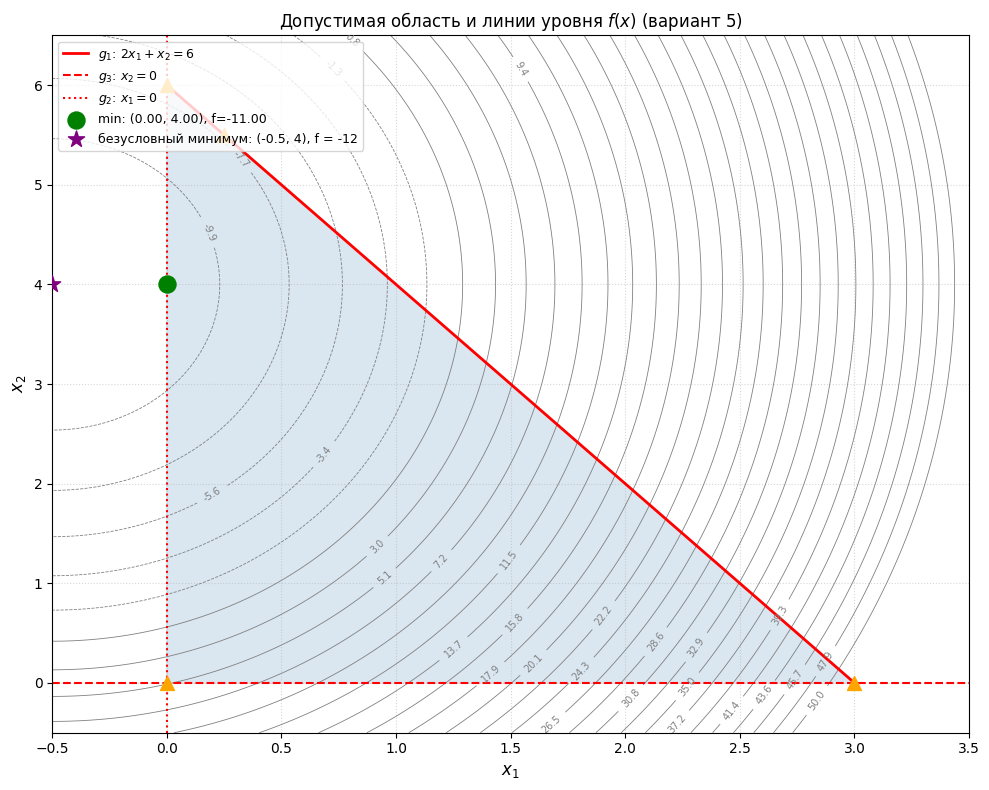

In [ ]:
# %%
x1_r = np.linspace(-0.5, 3.5, 500)
x2_r = np.linspace(-0.5, 6.5, 500)
X1, X2 = np.meshgrid(x1_r, x2_r)

F = 4*X1**2 + 4*X1 + X2**2 - 8*X2 + 5
feasible = (X1 >= 0) & (X2 >= 0) & (2*X1 + X2 - 6 <= 0)

plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], alpha=0.2, colors=['steelblue'])

levels = np.linspace(-12, 50, 30)
cs = plt.contour(X1, X2, F, levels=levels, colors='gray', linewidths=0.6)
plt.clabel(cs, inline=True, fontsize=7, fmt='%.1f')

x1_boundary = np.linspace(0, 3, 100)
x2_boundary = 6 - 2*x1_boundary
plt.plot(x1_boundary, x2_boundary, 'r-', lw=2, label='$g_1$: $2x_1 + x_2 = 6$')

plt.axhline(0, color='r', lw=1.5, linestyle='--', label='$g_3$: $x_2 = 0$')
plt.axvline(0, color='r', lw=1.5, linestyle=':', label='$g_2$: $x_1 = 0$')

for key, pt in unique_pts.items():
    res = check_second_order(pt, L, g_list, [x1, x2])
    if 'минимум' in res:
        plt.scatter(pt['x1'], pt['x2'], c='green', s=150, zorder=5,
                    label=f"min: ({pt['x1']:.2f}, {pt['x2']:.2f}), f={pt['f']:.2f}")
    else:
        plt.scatter(pt['x1'], pt['x2'], c='orange', s=100, marker='^', zorder=5)

plt.scatter(-0.5, 4, c='purple', s=150, marker='*', zorder=5,
            label=f'безусловный минимум: (-0.5, 4), f = -12')

plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Допустимая область и линии уровня $f(x)$ (вариант 5)')
plt.legend(loc='upper left', fontsize=9)
plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 6.5)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Выводы

Для задачи условной оптимизации (вариант 5) методом условий Куна–Такера (ККТ) найдены стационарные точки.

**Алгоритм решения:**
1. Составлена классическая функция Лагранжа
2. Записаны условия стационарности и дополняющей нежёсткости
3. Для всех 8 комбинаций активных/пассивных ограничений решена система уравнений
4. Проверены условия допустимости и неотрицательности множителей Лагранжа
5. Для каждой ККТ-точки исследованы достаточные условия второго порядка

**Результаты:**

1. **Точка (0, 0)** — условный локальный минимум:
   - f(0, 0) = 5
   - Активные ограничения: g₂ (x₁ = 0) и g₃ (x₂ = 0)

2. **Точка (0, 5)** — условный локальный минимум:
   - f(0, 5) = -6
   - Активные ограничения: g₁ (2x₁ + x₂ = 6) и g₂ (x₁ = 0)